# Regresión: 7 modelos x 4 optimizadores sobre `TARGET`

Este capítulo ejecuta las **28 combinaciones** de regresión de la Sección 2 (7 modelos x 4
optimizadores; el balanceo no aplica en regresión). Por decisión de diseño del proyecto, **la
variable objetivo y la métrica son las mismas que en clasificación**: `TARGET` (1 = dificultades
de pago) y AUC-ROC. El objetivo es una evaluación general y homogénea de los 14 algoritmos sobre
un mismo problema de negocio.

## 1. Qué significa una regresión sobre un objetivo 0/1

Un regresor que minimiza el error cuadrático estima la media condicional del objetivo. Con
`TARGET` en {0, 1}:

$$\hat f(x) \approx \mathbb{E}[Y \mid X = x] = P(Y = 1 \mid X = x)$$

es decir, **estima la probabilidad de incumplimiento**, igual que un clasificador probabilístico.
Su predicción funciona como puntaje de riesgo, y el AUC-ROC, que solo depende del orden de los
puntajes, se calcula exactamente igual que en clasificación. En el caso lineal (Ridge, Lasso) es el
llamado *modelo de probabilidad lineal*.

Consecuencias que se esperan antes de mirar los resultados:

* **AUC.** Los regresores flexibles deberían ordenar casi igual que sus contrapartes de
  clasificación. En el árbol CART la equivalencia es exacta en los cortes: la varianza de un nodo
  con proporción p de positivos es p(1-p), que es la mitad del índice de Gini. En KNN el promedio
  de las etiquetas de los vecinos *es* la probabilidad del clasificador. En el bosque (bosque
  aleatorio de XGBoost) el clasificador optimiza la log-verosimilitud y el regresor el error
  cuadrático, de modo que sus cortes son parecidos pero no idénticos.
* **SVR** es el caso problemático: su pérdida ε-insensible es de tipo absoluto y tiende a estimar la
  mediana condicional, que es 0 para casi todos los solicitantes (8 % de positivos). Cabe esperar
  puntajes comprimidos hacia 0 y un ordenamiento peor y más sensible a `C` y `ε`.
* **RMSE.** Con objetivo 0/1, el error cuadrático medio del puntaje es el Brier score: el RMSE
  reportado es su raíz. Predecir siempre la tasa base (0.0807) da RMSE = √(0.0807·0.9193) ≈ 0.272,
  de modo que mejoras que parecen pequeñas en RMSE corresponden a diferencias grandes de AUC.
* **MAE.** Predecir siempre 0 da MAE = 0.081, que ningún modelo probabilístico razonable supera: el
  MAE premia estimar la mediana (0), no ordenar el riesgo. Se reporta porque la guía lo exige y el
  capítulo 07 explica por qué no sirve para decidir en este problema.
* **Supuestos de residuos.** El residuo solo toma dos valores por observación (−ŷ o 1 − ŷ) y su
  varianza condicional es p(1-p): White y las pruebas de normalidad rechazarán por construcción.

El diseño experimental (CV anidada 5 x 3, 20 evaluaciones por optimizador, preprocesamiento en
cache, ejecución reanudable) es idéntico al del capítulo 02. Los pliegues externos son **los
mismos** que en clasificación, de modo que las predicciones fuera de muestra de los 140 modelos son
comparables observación por observación (lo exige el capítulo 09).

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
from src import datos, preprocesamiento as prep, experimento as ex, espacios

conj = datos.cargar_traspaso()
display(conj.describir())
prep.preparar_particiones(conj)     # reutiliza la cache del capítulo 02 si ya existe
del conj
import gc; gc.collect();

,Particion,Filas,Positivos,Mora_%,Columnas,Cuantitativas,Cualitativas
0,desarrollo,246008,19860,8.07,483,467,16
1,prueba,61503,4965,8.07,483,467,16


## 2. Espacios de búsqueda

Árbol, bosque, XGBoost y KNN comparten los espacios de clasificación. Los propios de regresión:

* **Ridge:** `alpha` en [1e-2, 1e5] (log). Con ~600 columnas estandarizadas y ~130 mil filas, la
  penalización empieza a ser relevante frente a `X'X` (del orden de n) a partir de `alpha ~ 1e3`;
  el rango cubre desde prácticamente MCO hasta una contracción fuerte.
* **Lasso:** `alpha` en [1e-6, 1e-1] (log). La varianza de `TARGET` es 0.074; a partir de
  `alpha ~ 0.1` la penalización anula todos los coeficientes.
* **SVR:** `C` en [1e-4, 10] (log), `ε` en [0, 0.3] y el mismo núcleo que SVM. Un `ε ≥ 0.5` haría que
  todas las observaciones negativas (y ≈ 0) quedaran dentro del tubo con una predicción cercana a 0.

In [3]:
tabla = espacios.tabla_espacios()
display(tabla[tabla["Tarea"] == "regresion"].drop(columns="Tarea"))

,Modelo,Hiperparametro,Rango,Escala,Activo si
24,knn,n_vecinos,"[5, 300]",log,siempre
25,knn,ponderacion,"uniform, distance",categorica,siempre
26,knn,n_componentes,"[10, 80]",lineal,siempre
27,ridge,alpha,"[0.01, 100000]",log,siempre
28,lasso,alpha,"[1e-06, 0.1]",log,siempre
29,arbol,max_depth,"[3, 20]",lineal,siempre
30,arbol,min_samples_leaf,"[10, 2000]",log,siempre
31,arbol,max_features,"sqrt, 0.3, 1.0",categorica,siempre
32,random_forest,n_estimators,"[100, 300]",lineal,siempre
33,random_forest,max_depth,"[6, 16]",lineal,siempre


In [4]:
ESTIMAR_TIEMPOS = False     # cambie a True para medir antes de lanzar
if ESTIMAR_TIEMPOS:
    estimacion = ex.estimar_tiempos("regresion")
    display(estimacion)
    estimacion.to_csv(config.DIR_RESULTADOS / "estimacion_tiempos_regresion.csv", index=False)

## 3. Ejecución por modelo

Cada celda ejecuta las 20 unidades de un modelo (5 pliegues x 4 optimizadores), con las mismas
garantías del capítulo 02: reanudable, guardado por unidad y errores aislados.
Como en el capítulo 02, el estudio se ejecutó fuera de Jupyter con los mismos scripts (anexo A); aquí
las celdas encuentran sus unidades hechas.

In [5]:
ex.avance("regresion")

,tarea,modelo,hechas,totales,con_error
0,regresion,knn,20,20,0
1,regresion,ridge,20,20,0
2,regresion,lasso,20,20,0
3,regresion,arbol,20,20,0
4,regresion,random_forest,20,20,0
5,regresion,xgboost,20,20,0
6,regresion,svr,20,20,0


### KNN regresor (`knn`)

Promedio (o promedio ponderado por distancia) de `TARGET` en los k vecinos: coincide exactamente con la probabilidad del KNN clasificador. Búsqueda exacta de vecinos (PyTorch en la GPU o FAISS en la CPU: mismos vecinos).

In [6]:
estado_knn = ex.ejecutar("regresion", modelos=["knn"])

20 unidades | ya hechas: 20 | pendientes: 0

Resumen: {'hecha': 20} | tiempo de esta ejecucion: 0.00 h


### Ridge (`ridge`)

Penalización L2; solución por Cholesky, O(n p² + p³).

In [7]:
estado_ridge = ex.ejecutar("regresion", modelos=["ridge"])

20 unidades | ya hechas: 20 | pendientes: 0



Resumen: {'hecha': 20} | tiempo de esta ejecucion: 0.00 h


### Lasso (`lasso`)

Penalización L1; descenso por coordenadas con matriz de Gram precalculada.

In [8]:
estado_lasso = ex.ejecutar("regresion", modelos=["lasso"])

20 unidades | ya hechas: 20 | pendientes: 0



Resumen: {'hecha': 20} | tiempo de esta ejecucion: 0.00 h


### Árbol de regresión (`arbol`)

El criterio de error cuadrático sobre un objetivo 0/1 es la varianza p(1-p) de cada nodo, es decir, la mitad del índice de Gini: hace los mismos cortes que el árbol clasificador.

In [9]:
estado_arbol = ex.ejecutar("regresion", modelos=["arbol"])

20 unidades | ya hechas: 20 | pendientes: 0



Resumen: {'hecha': 20} | tiempo de esta ejecucion: 0.00 h


### Random Forest regresor (`random_forest`)

Bosque aleatorio de XGBoost en la GPU (`XGBRFRegressor`); con pérdida cuadrática, `min_child_weight` equivale exactamente a `min_samples_leaf`.

In [10]:
estado_random_forest = ex.ejecutar("regresion", modelos=["random_forest"])

20 unidades | ya hechas: 20 | pendientes: 0



Resumen: {'hecha': 20} | tiempo de esta ejecucion: 0.00 h


### XGBoost regresor (`xgboost`)

`reg:squarederror`, `hist`, parada temprana por RMSE, GPU si existe.

In [11]:
estado_xgboost = ex.ejecutar("regresion", modelos=["xgboost"])

20 unidades | ya hechas: 20 | pendientes: 0



Resumen: {'hecha': 20} | tiempo de esta ejecucion: 0.00 h


### SVR (`svr`)

`LinearSVR` con pérdida ε-insensible estándar, o Nystroem (RBF aproximado) + `LinearSVR`.

In [12]:
estado_svr = ex.ejecutar("regresion", modelos=["svr"])

20 unidades | ya hechas: 20 | pendientes: 0



Resumen: {'hecha': 20} | tiempo de esta ejecucion: 0.00 h


## 4. Verificación y tabla maestra

In [13]:
display(ex.avance("regresion"))
pliegues, maestra = ex.consolidar()
reg = maestra[maestra["tarea"] == "regresion"]
cols = ["modelo", "optimizador", "m_auc_roc_media", "m_auc_roc_sd", "m_rmse_media", "m_rmse_sd",
        "m_mae_media", "m_r2_media", "evaluaciones_total", "t_total_h"]
print(f"Combinaciones completas: {(reg['pliegues'] == config.N_EXTERNOS).sum()} de 28")
display(reg[cols].style.format(precision=4).hide(axis="index"))

,tarea,modelo,hechas,totales,con_error
0,regresion,knn,20,20,0
1,regresion,ridge,20,20,0
2,regresion,lasso,20,20,0
3,regresion,arbol,20,20,0
4,regresion,random_forest,20,20,0
5,regresion,xgboost,20,20,0
6,regresion,svr,20,20,0


Combinaciones completas: 28 de 28


modelo,optimizador,m_auc_roc_media,m_auc_roc_sd,m_rmse_media,m_rmse_sd,m_mae_media,m_r2_media,evaluaciones_total,t_total_h
xgboost,bayesiana,0.7695,0.0032,0.2596,0.0003,0.1366,0.0921,100,2.3612
xgboost,aleatoria,0.7692,0.0027,0.2597,0.0004,0.1370,0.0913,100,1.7054
xgboost,rejilla,0.7686,0.0031,0.2595,0.0003,0.1361,0.0924,80,1.8807
xgboost,genetica,0.7680,0.0031,0.2598,0.0003,0.1370,0.0906,100,2.0975
lasso,aleatoria,0.7554,0.0026,0.2628,0.0002,0.1448,0.0691,100,0.0662
lasso,rejilla,0.7553,0.0025,0.2628,0.0002,0.1447,0.0691,100,0.0680
lasso,bayesiana,0.7553,0.0025,0.2628,0.0002,0.1447,0.0691,100,0.0692
lasso,genetica,0.7553,0.0025,0.2629,0.0002,0.1447,0.0690,100,0.0659
ridge,bayesiana,0.7549,0.0026,0.2629,0.0003,0.1451,0.0685,100,0.1014
ridge,rejilla,0.7548,0.0025,0.2629,0.0002,0.1449,0.0685,100,0.1858


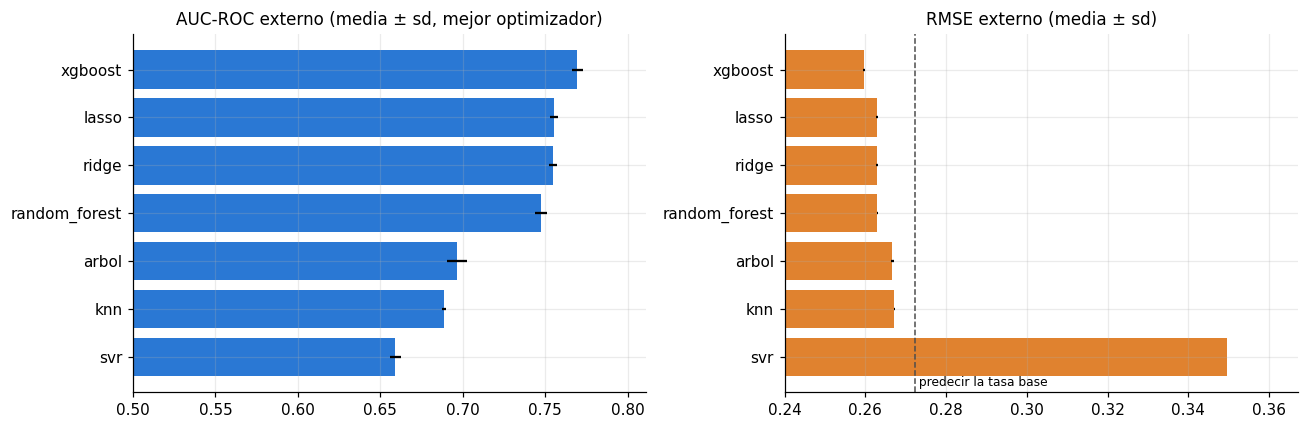

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
mejor = reg.loc[reg.groupby("modelo")["m_auc_roc_media"].idxmax()].sort_values("m_auc_roc_media")
ax[0].barh(mejor["modelo"], mejor["m_auc_roc_media"], xerr=mejor["m_auc_roc_sd"], color="#2a78d4")
ax[0].set_xlim(0.5, None)
ax[0].set_title("AUC-ROC externo (media ± sd, mejor optimizador)")
ax[1].barh(mejor["modelo"], mejor["m_rmse_media"], xerr=mejor["m_rmse_sd"], color="#e0822f")
ax[1].axvline(np.sqrt(0.0807 * 0.9193), color="0.3", ls="--", lw=1)
ax[1].text(np.sqrt(0.0807 * 0.9193), -0.6, " predecir la tasa base", fontsize=8)
ax[1].set_xlim(0.24, None)
ax[1].set_title("RMSE externo (media ± sd)")
fig.tight_layout()
graficos.guardar(fig, "03_regresores_auc_rmse")
plt.show()

**Lectura.** **Orden por AUC frente a orden por RMSE.** Coinciden en los extremos y no en el medio.
XGBoost es el mejor por ambos criterios (AUC 0.7695, RMSE 0.2596) y SVR el peor. Pero Random Forest,
con un AUC 0.008 menor que Lasso y Ridge, tiene un RMSE comparable: 0.2624 con rejilla, mejor que el
de Lasso y Ridge (0.2628-0.2629). Con un objetivo 0/1 el RMSE es la raíz del Brier, que mezcla discriminación y
calibración: los modelos lineales de probabilidad ordenan mejor, pero producen predicciones fuera de
[0, 1] que el error cuadrático penaliza (capítulo 07, sección 3).

**Regresores flexibles frente a sus contrapartes de clasificación.** La predicción teórica se cumple
con exactitud donde debía. El árbol (0.6965) y KNN (0.6887) dan el mismo AUC externo medio que en el
capítulo 02: con error cuadrático y con Gini se eligen los mismos cortes, y el promedio de las
etiquetas de los vecinos es la misma probabilidad. En XGBoost y Random Forest la regresión queda
0.0026 y 0.0021 por debajo, menos que una desviación entre pliegues. Lasso y Ridge (0.7554 y 0.7549)
quedan 0.002-0.003 por debajo de la logística (0.7576): el enlace logit se ajusta algo mejor a un
objetivo binario que el modelo lineal de probabilidad.

**SVR.** Se comporta como anticipaba la sección 1, y peor. Es el único regresor con R² negativo en
todas sus variantes (−0.08 a −0.65) y con un RMSE peor que predecir la tasa base (0.283-0.350 frente a
0.272): sus predicciones quedan comprimidas en una franja estrecha (el capítulo 07 muestra que el
modelo final predice prácticamente una constante). Su ordenamiento es el peor (AUC 0.629-0.659) y el
más inestable entre optimizadores (desviación entre pliegues de 0.019 con la bayesiana), y aun así fue
el regresor más costoso del estudio (26 horas de cómputo; anexo A).